# 5. LISA response and the global-fit problem

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Designed for Google Colab. Run top to bottom; **Extension** sections may be skipped live.


## Why LISA is different

| Observatory | Approximate band | Response picture |
| --- | --- | --- |
| LVK | tens of Hz to kHz | short signals in separated, nearly rigid detectors |
| LISA | roughly $10^{-4}$ to $10^{-1}$ Hz | orbital modulation, finite arms, delayed links, TDI |

LISA observes long-lived Galactic binaries, massive-black-hole binaries, EMRIs, stellar-origin binaries, and stochastic signals. Many overlap in time and frequency, while instrument noise is also uncertain.

In [1]:
import os, sys, subprocess, importlib.util
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
if importlib.util.find_spec("jaxgb") is None:
    if IN_COLAB: subprocess.check_call([sys.executable,"-m","pip","install","-q","jaxgb==0.2.1","astropy==7.2.0"])
    else: raise ImportError("Install jaxgb==0.2.1 and astropy==7.2.0, or run in Colab.")

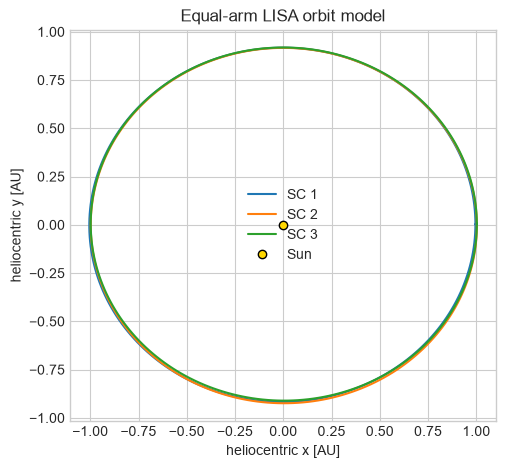

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config
config.update("jax_enable_x64", True)
from lisaorbits import EqualArmlengthOrbits
from jaxgb.jaxgb import JaxGB
from jaxgb.params import GBObject
rng=np.random.default_rng(20260817); plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["animation.html"]="jshtml"
year=365.25*86400; AU=149597870700.; orbits=EqualArmlengthOrbits(); times=np.linspace(0,year,240)
positions=np.asarray(orbits.compute_position(times,[1,2,3])); fig,ax=plt.subplots(figsize=(5.5,5.5))
for i,label in enumerate(["SC 1","SC 2","SC 3"]): ax.plot(positions[:,i,0]/AU,positions[:,i,1]/AU,label=label)
ax.plot(0,0,"o",color="gold",mec="k",label="Sun"); ax.set(xlabel="heliocentric x [AU]",ylabel="heliocentric y [AU]",title="Equal-arm LISA orbit model",aspect="equal"); ax.legend(); plt.show()

The triangle orbits and cartwheels. A wave reaches six one-way laser links at different retarded times. Time-delay interferometry combines delayed links to suppress laser-frequency noise. Long observations therefore have orbital modulation and finite-arm transfer features, not three constant antenna factors.

## A real JaxGB response

A Galactic binary uses $(f_0,\dot f,A,\alpha,\delta,\psi,\iota,\phi_0)$. JaxGB evaluates the moving-constellation link/TDI response.

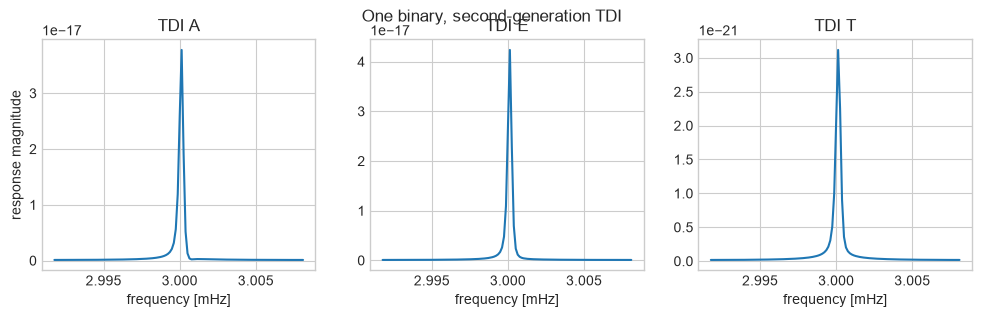

In [3]:
t_obs=90*86400; response=JaxGB(orbits,t_obs=t_obs,t0=0,n=128)
binary=GBObject(f0=np.array([3e-3]),fdot=np.array([1e-17]),A=np.array([2e-22]),ra=np.array([1.]),dec=np.array([.4]),psi=np.array([.3]),iota=np.array([.8]),phi0=np.array([.2]),t_init=0.)
pars=binary.to_jaxgb_array(t0=0); A,E,T=response.get_tdi(pars,tdi_generation=2,tdi_combination="AET"); freq=np.asarray(response.get_frequency_grid(response.get_kmin(pars[:,0])))[0]
fig,axes=plt.subplots(1,3,figsize=(12,3),sharex=True)
for ax,channel,name in zip(axes,[A,E,T],["A","E","T"]): ax.plot(1e3*freq,np.abs(np.asarray(channel)[0])); ax.set_title(f"TDI {name}"); ax.set_xlabel("frequency [mHz]")
axes[0].set_ylabel("response magnitude"); fig.suptitle("One binary, second-generation TDI"); plt.show()

## The global-fit model

The LISA Data Challenge demonstration used
\[
d=h_{\rm UCB}+h_{\rm VGB}+h_{\rm MBHB}+n(\eta),
\]
updating source/noise blocks against residuals containing current estimates of all other blocks. GLASS simultaneously handled thousands of overlapping sources and unknown noise.

Our mini challenge has three nearby JaxGB sources. We fix their nonlinear parameters/noise and infer only amplitude multipliers: small enough to compare one-pass subtraction, joint fitting, and blocked updates.

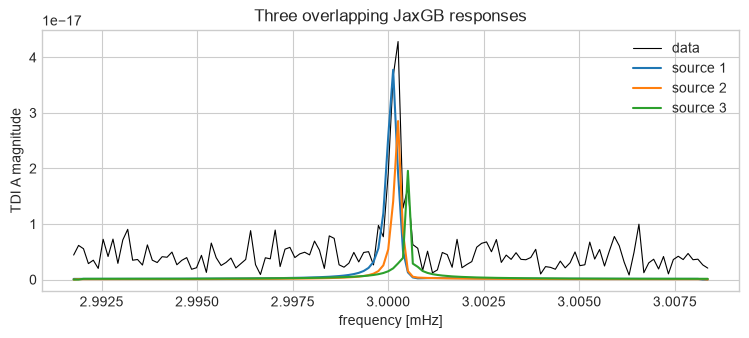

In [4]:
frequencies=np.array([3e-3,3.00012e-3,3.00025e-3]); true_scales=np.array([1.,.72,.48])
catalogue=GBObject(f0=frequencies,fdot=np.array([1e-17,.5e-17,1.5e-17]),A=np.full(3,2e-22),ra=np.array([1.,1.4,2.]),dec=np.array([.4,-.2,.7]),psi=np.array([.3,.8,1.1]),iota=np.array([.8,1.2,.5]),phi0=np.array([.2,1.5,2.4]),t_init=0.)
p_all=catalogue.to_jaxgb_array(t0=0); kmins=np.asarray(response.get_kmin(p_all[:,0])); kmin=int(np.min(kmins)); kmax=int(np.max(kmins)+response.n)
templates=[]
for row in np.asarray(p_all):
    a,_,_=response.sum_tdi(row[None,:],kmin,kmax,tdi_generation=2,tdi_combination="AET"); templates.append(np.asarray(a))
templates=np.asarray(templates); model=np.sum(true_scales[:,None]*templates,axis=0); noise_sigma=.08*np.max(np.abs(model))
data=model+noise_sigma*(rng.normal(size=model.size)+1j*rng.normal(size=model.size)); common_f=np.arange(kmin,kmax)/t_obs
fig,ax=plt.subplots(figsize=(9,3.4)); ax.plot(1e3*common_f,np.abs(data),color="k",lw=.8,label="data")
for i,tpl in enumerate(templates): ax.plot(1e3*common_f,np.abs(true_scales[i]*tpl),label=f"source {i+1}")
ax.set(xlabel="frequency [mHz]",ylabel="TDI A magnitude",title="Three overlapping JaxGB responses"); ax.legend(); plt.show()

true       [1.   0.72 0.48]
one pass   [0.982 0.726 0.437]
joint      [1.009 0.748 0.439]
blocked    [1.009 0.748 0.439]


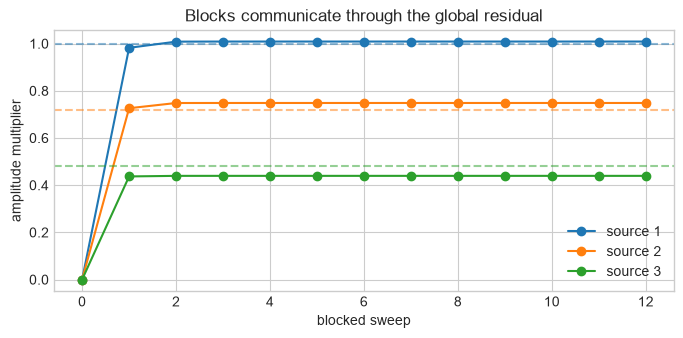

In [5]:
sequential=np.zeros(3); residual=data.copy()
for i,tpl in enumerate(templates): sequential[i]=np.real(np.vdot(tpl,residual)/np.vdot(tpl,tpl)); residual-=sequential[i]*tpl
X=templates.T; joint=np.linalg.lstsq(np.vstack([X.real,X.imag]),np.r_[data.real,data.imag],rcond=None)[0]
blocked=np.zeros(3); history=[blocked.copy()]
for iteration in range(12):
    for i,tpl in enumerate(templates):
        effective=data-np.sum(blocked[:,None]*templates,axis=0)+blocked[i]*tpl
        blocked[i]=np.real(np.vdot(tpl,effective)/np.vdot(tpl,tpl))
    history.append(blocked.copy())
history=np.asarray(history)
print("true      ",np.round(true_scales,3)); print("one pass  ",np.round(sequential,3)); print("joint     ",np.round(joint,3)); print("blocked   ",np.round(blocked,3))
fig,ax=plt.subplots(figsize=(8,3.4))
for i in range(3): ax.plot(history[:,i],"o-",label=f"source {i+1}"); ax.axhline(true_scales[i],color=f"C{i}",ls="--",alpha=.5)
ax.set(xlabel="blocked sweep",ylabel="amplitude multiplier",title="Blocks communicate through the global residual"); ax.legend(); plt.show()

## Extension: animate the residual

In [6]:
fig,ax=plt.subplots(figsize=(9,3.3)); line,=ax.plot([],[],lw=.8)
ax.set(xlim=(1e3*common_f.min(),1e3*common_f.max()),ylim=(0,1.1*np.max(np.abs(data))),xlabel="frequency [mHz]",ylabel="residual magnitude")
def update(i):
    r=data-np.sum(history[i,:,None]*templates,axis=0); line.set_data(1e3*common_f,np.abs(r)); ax.set_title(f"global residual after sweep {i}"); return (line,)
animation=FuncAnimation(fig,update,frames=len(history),interval=220); plt.close(fig); display(HTML(animation.to_jshtml()))

## Optional LISA Data Challenge input

The LDC file portal redirects unauthenticated visitors to login. Do not make the live class depend on it; authenticated students may upload a selected file into Colab afterward.

In [7]:
RUN_LDC_UPLOAD=False
if RUN_LDC_UPLOAD:
    if not IN_COLAB: raise RuntimeError("Upload helper is for Colab.")
    from google.colab import files
    uploaded=files.upload(); print("Uploaded:",list(uploaded))
else: print("Optional authenticated portal: https://lisa-ldc.in2p3.fr/file")

Optional authenticated portal: https://lisa-ldc.in2p3.fr/file


## Boundary

This uses a real orbit/TDI response but only three Galactic binaries and one fitted TDI channel. Frequencies, phases, sky positions, source count, and noise were fixed. Research global fits need probabilistic sampling, birth/death moves, multiple TDI channels and source classes, inferred noise, and convergence/coverage validation.

- [GLASS global analysis](https://arxiv.org/abs/2301.03673)
- [LISA Data Challenge files](https://lisa-ldc.in2p3.fr/file)
- [JaxGB](https://pypi.org/project/jaxgb/)
- [LISA GW Response](https://lisa-simulation.pages.in2p3.fr/gw-response/)